In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import integrate

In [ ]:
# Параметры области решения
radius = 1.0
r_points, theta_points = 50, 200
r_values = np.linspace(0.0, radius, r_points)
theta_values = np.linspace(0, 2*np.pi, theta_points)
dr = r_values[1] - r_values[0]
dtheta = theta_values[1] - theta_values[0]

# Граничное условие
boundary_func = lambda theta: 3*np.cos(theta) - 4*np.sin(3*theta)

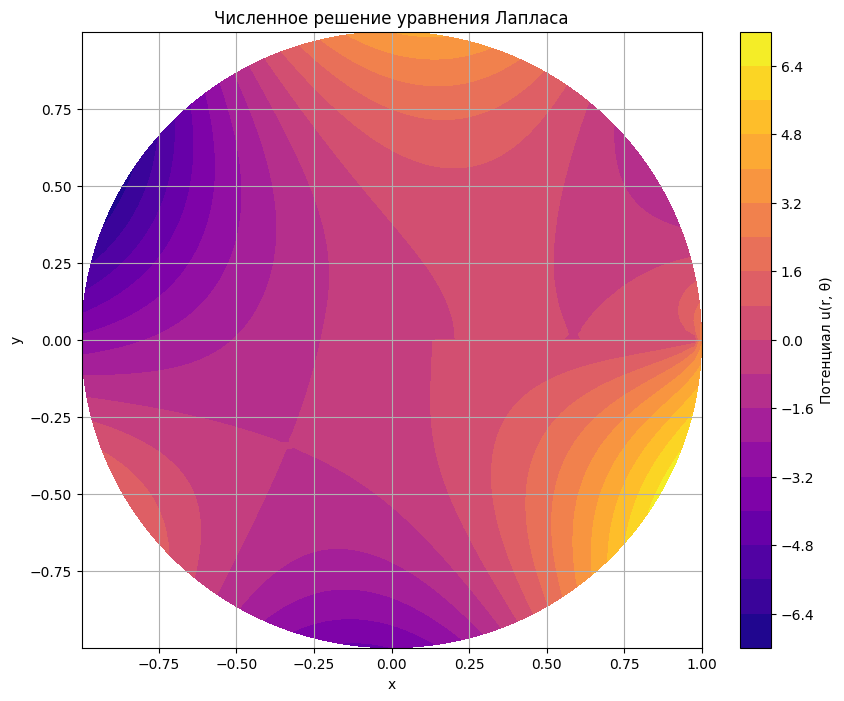

In [ ]:
# Численное решение
def finite_difference_solution(r_min, r_max, theta_min, theta_max, Nr, Ntheta, tol=1e-5, max_iter=10000):
    r = np.linspace(r_min, r_max, Nr)
    theta = np.linspace(theta_min, theta_max, Ntheta)
    solution = np.zeros((Nr, Ntheta))

    # Устанавливаем граничные условия
    solution[-1, :] = boundary_func(theta)

    for iteration in range(max_iter):
        prev_solution = solution.copy()
        for i in range(1, Nr-1):
            ri = r[i]
            for j in range(1, Ntheta-1):
                # Дискретизация уравнения Лапласа в полярных координатах
                radial_part = (prev_solution[i+1,j] + prev_solution[i-1,j]) / dr**2
                angular_part = (prev_solution[i,j+1] + prev_solution[i,j-1]) / (ri**2 * dtheta**2)
                mixed_part = (prev_solution[i+1,j] - prev_solution[i-1,j]) / (2 * ri * dr)

                solution[i,j] = (radial_part + angular_part + mixed_part) / \
                               (2/dr**2 + 2/(ri**2 * dtheta**2))

        if np.max(np.abs(solution - prev_solution)) < tol:
            print(f"Численный метод сошелся за {iteration} итераций")
            break

    return r, theta, solution

r_num, theta_num, u_num = finite_difference_solution(0, radius, 0, 2*np.pi, r_points, theta_points)

# Визуализация численного решения
R, Theta = np.meshgrid(r_num, theta_num, indexing='ij')
X_num, Y_num = R * np.cos(Theta), R * np.sin(Theta)

plt.figure(figsize=(10, 8))
plt.contourf(X_num, Y_num, u_num, levels=20, cmap='plasma')
plt.colorbar(label='Потенциал u(r, θ)')
plt.title('Численное решение уравнения Лапласа')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True)
plt.show()

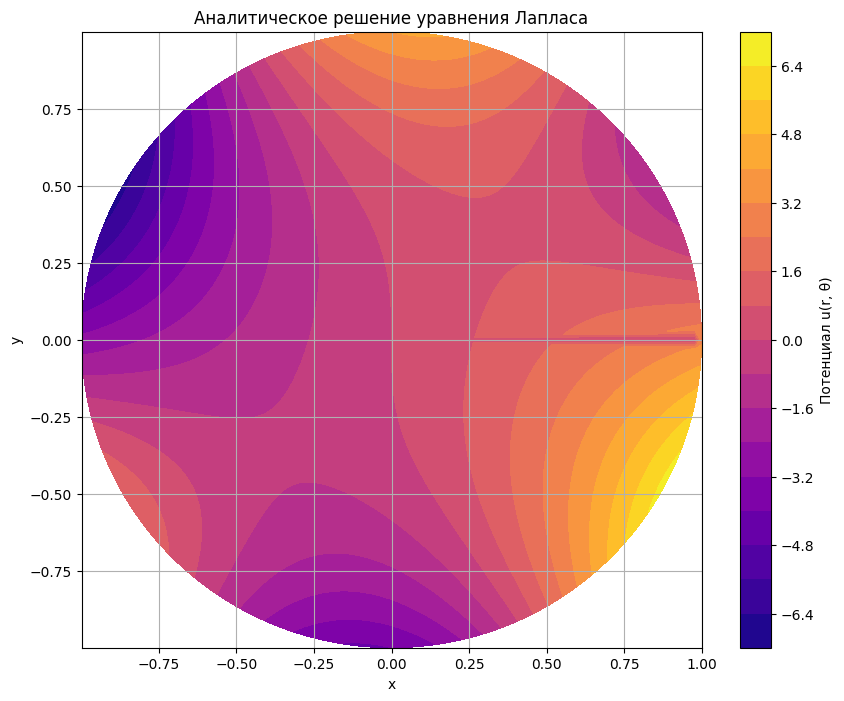

In [ ]:
### Метод 2: Аналитическое решение ###
def analytical_solution(r, theta):
    return 3 * r * np.cos(theta) - 4 * r**3 * np.sin(3*theta)

u_analytical = np.zeros((r_points, theta_points))
u_analytical[-1, :] = boundary_func(theta_values)

for i in range(1, r_points-1):
    for j in range(1, theta_points-1):
        u_analytical[i,j] = analytical_solution(dr*i, j*dtheta)

# Визуализация аналитического решения
X_anal, Y_anal = R * np.cos(Theta), R * np.sin(Theta)

plt.figure(figsize=(10, 8))
plt.contourf(X_anal, Y_anal, u_analytical, levels=20, cmap='plasma')
plt.colorbar(label='Потенциал u(r, θ)')
plt.title('Аналитическое решение уравнения Лапласа')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True)
plt.show()

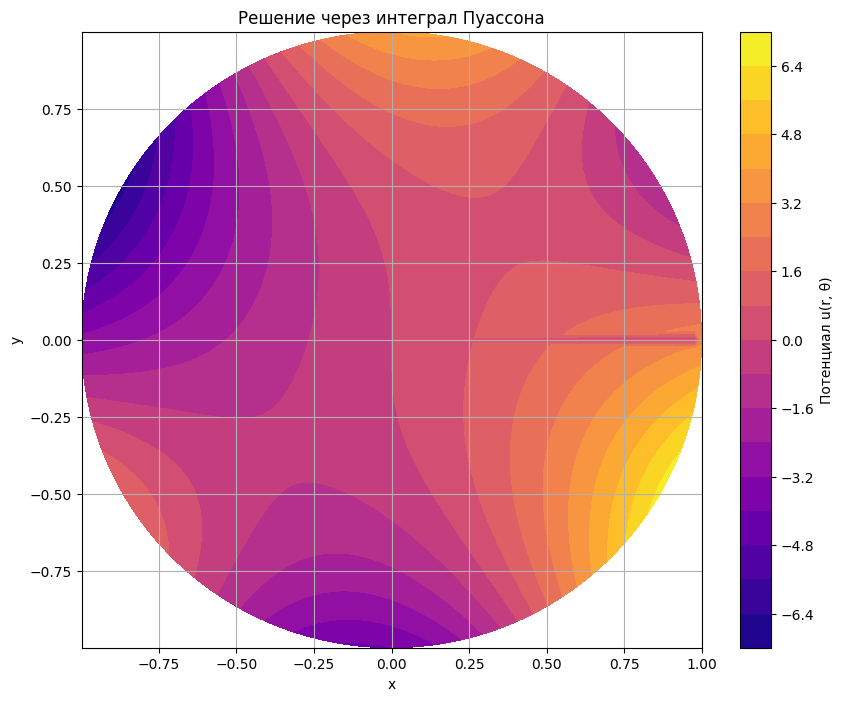

In [ ]:
### Метод 3: Интеграл Пуассона ###
def poisson_kernel(psi, r, phi, a=radius):
    numerator = a**2 - r**2
    denominator = a**2 - 2*a*r*np.cos(phi - psi) + r**2
    return numerator / denominator

def poisson_integral(psi, r, phi):
    return (1/(2*np.pi)) * poisson_kernel(psi, r, phi) * boundary_func(psi)

u_poisson = np.zeros((r_points, theta_points))
u_poisson[-1, :] = boundary_func(theta_values)

for i in range(1, r_points-1):
    for j in range(1, theta_points-1):
        integral_result = integrate.quad(poisson_integral, 0, 2*np.pi, args=(dr*i, j*dtheta))
        u_poisson[i,j] = integral_result[0]

# Визуализация решения через интеграл Пуассона
X_poiss, Y_poiss = R * np.cos(Theta), R * np.sin(Theta)

plt.figure(figsize=(10, 8))
plt.contourf(X_poiss, Y_poiss, u_poisson, levels=20, cmap='plasma')
plt.colorbar(label='Потенциал u(r, θ)')
plt.title('Решение через интеграл Пуассона')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True)
plt.show()